# Homework 9

In [41]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


## Data Selection and Preparation

In [42]:
# Load the CSV file for the training dataset
data = pd.read_csv('world-data-2023.csv')
df = pd.DataFrame(data)

df.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [55]:
# the list of columns i selected
child_df= df[['Gross primary education enrollment (%)', 'Infant mortality', 'Maternal mortality ratio','Out of pocket health expenditure','Physicians per thousand']]
child_df_2 = df[['GDP','Gross primary education enrollment (%)', 'Infant mortality', 'Maternal mortality ratio','Out of pocket health expenditure','Physicians per thousand','Birth Rate','Life expectancy','Unemployment rate','Fertility Rate']]


In [65]:
child_df_2 = df[[ 'Density\n(P/Km2)', 'Agricultural Land( %)', 'Armed Forces size', 'Birth Rate', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Fertility Rate', 'Forested Area (%)',
       'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude']]

In [75]:
child_df_2

,Density\n(P/Km2),Agricultural Land( %),Armed Forces size,Birth Rate,Co2-Emissions,CPI,CPI Change (%),Fertility Rate,Forested Area (%),GDP,...,Out of pocket health expenditure,Physicians per thousand,Population,Population: Labor force participation (%),Tax revenue (%),Total tax rate,Unemployment rate,Urban_population,Latitude,Longitude
0,60,58.10%,"323,000",32.49,"8,672",149.9,2.30%,4.47,2.10%,1.910135e+10,...,0.784,0.28,"38,041,754",48.90%,9.30%,71.40%,0.1112,"9,797,273",33.939110,67.709953
1,105,43.10%,"9,000",11.78,"4,536",119.05,1.40%,1.62,28.10%,1.527808e+10,...,0.569,1.20,"2,854,191",55.70%,18.60%,36.60%,0.1233,"1,747,593",41.153332,20.168331
2,18,17.40%,"317,000",24.28,"150,006",151.36,2.00%,3.02,0.80%,1.699882e+11,...,0.281,1.72,"43,053,054",41.20%,37.20%,66.10%,0.1170,"31,510,100",28.033886,1.659626
4,26,47.50%,"117,000",40.73,"34,693",261.73,17.10%,5.52,46.30%,9.463542e+10,...,0.334,0.21,"31,825,295",77.50%,9.20%,49.10%,0.0689,"21,061,025",-11.202692,17.873887
6,17,54.30%,"105,000",17.02,"201,348",232.75,53.50%,2.26,9.80%,4.496634e+11,...,0.176,3.96,"44,938,712",61.30%,10.10%,106.30%,0.0979,"41,339,571",-38.416097,-63.616672
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,281,71.70%,"148,000",11.00,"379,025",119.62,1.70%,1.68,13.10%,2.827113e+12,...,0.148,2.81,"66,834,405",62.80%,25.50%,30.60%,0.0385,"55,908,316",55.378051,-3.435973
186,36,44.40%,"1,359,000",11.60,"5,006,302",117.24,7.50%,1.73,33.90%,2.142770e+13,...,0.111,2.61,"328,239,523",62.00%,9.60%,36.60%,0.1470,"270,663,028",37.090240,-95.712891
187,20,82.60%,"22,000",13.86,"6,766",202.92,7.90%,1.97,10.70%,5.604591e+10,...,0.162,5.05,"3,461,734",64.00%,20.10%,41.80%,0.0873,"3,303,394",-32.522779,-55.765835
191,314,39.30%,"522,000",16.75,"192,668",163.52,2.80%,2.05,48.10%,2.619212e+11,...,0.435,0.82,"96,462,106",77.40%,19.10%,37.60%,0.0201,"35,332,140",14.058324,108.277199


### Data cleaning

In [56]:
# Before interpolation
print("NAs before:",child_df.isna().sum().sum())

# Interpolate
child_df.interpolate(inplace=True)

# Check results
print("NAs after:", child_df.isna().sum().sum())

# Drop the remaining missing values
child_df = child_df.dropna() 
child_df.isna().sum().sum() 


NAs before: 41
NAs after: 14


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/2812192955.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  child_df.interpolate(inplace=True)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/2812192955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df.interpolate(inplace=True)


np.int64(0)

In [67]:
# Before interpolation
print("NAs before:",child_df_2.isna().sum().sum())

# Interpolate
child_df_2.interpolate(inplace=True)

# Check results
print("NAs after:", child_df_2.isna().sum().sum())

# Drop the remaining missing values
child_df_2 = child_df_2.dropna() 
child_df_2.isna().sum().sum() 


NAs before: 283
NAs after: 233


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/688898729.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  child_df_2.interpolate(inplace=True)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/688898729.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2.interpolate(inplace=True)


np.int64(0)

In [86]:
child_df_2.dtypes

Density\n(P/Km2)                             float64
Agricultural Land( %)                        float64
Armed Forces size                            float64
Birth Rate                                   float64
Co2-Emissions                                float64
CPI                                          float64
CPI Change (%)                               float64
Fertility Rate                               float64
Forested Area (%)                            float64
GDP                                          float64
Gross primary education enrollment (%)       float64
Gross tertiary education enrollment (%)      float64
Infant mortality                             float64
Life expectancy                              float64
Maternal mortality ratio                     float64
Minimum wage                                 float64
Out of pocket health expenditure             float64
Physicians per thousand                      float64
Population                                   f

In [58]:
# convert values to float
child_df.dtypes

# Remove '$'
# child_df['GDP'] = child_df['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# Remove '%' and convert to decimals
child_df['Gross primary education enrollment (%)'] = child_df['Gross primary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df['Out of pocket health expenditure'] = child_df['Out of pocket health expenditure'].astype(str).str.replace('%', '').astype(float) / 100


In [85]:

# Remove '$'
child_df_2['GDP'] = child_df_2['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
child_df_2['Minimum wage'] = child_df_2['Minimum wage'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
child_df_2['Density\n(P/Km2)'] = child_df_2['Density\n(P/Km2)'].astype(str).str.replace(',', '').astype(float)
child_df_2['Armed Forces size'] = child_df_2['Armed Forces size'].astype(str).str.replace(',', '').astype(float)
child_df_2['Co2-Emissions'] = child_df_2['Co2-Emissions'].astype(str).str.replace(',', '').astype(float)
child_df_2['CPI'] = child_df_2['CPI'].astype(str).str.replace(',', '').astype(float)
child_df_2['Population'] = child_df_2['Population'].astype(str).str.replace(',', '').astype(float)
child_df_2['Urban_population'] = child_df_2['Urban_population'].astype(str).str.replace(',', '').astype(float)
child_df_2['Fertility Rate'] = child_df_2['Fertility Rate'].astype(float)

# Remove '%' and convert to decimals
child_df_2['Gross primary education enrollment (%)'] = child_df_2['Gross primary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Out of pocket health expenditure'] = child_df_2['Out of pocket health expenditure'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Unemployment rate'] = child_df_2['Unemployment rate'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Agricultural Land( %)'] = child_df_2['Agricultural Land( %)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['CPI Change (%)'] = child_df_2['CPI Change (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Forested Area (%)'] = child_df_2['Forested Area (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Gross tertiary education enrollment (%)'] = child_df_2['Gross tertiary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Population: Labor force participation (%)'] = child_df_2['Population: Labor force participation (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Tax revenue (%)'] = child_df_2['Tax revenue (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df_2['Total tax rate'] = child_df_2['Total tax rate'].astype(str).str.replace('%', '').astype(float) / 100
#เหลือเปอร์เซ้นต์


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/3773837257.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2['GDP'] = child_df_2['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/3773837257.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2['Minimum wage'] = child_df_2['Minimum wage'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
/var/folders/34/91r13ymj4sv1

### Data Preparation

In [59]:
# Standardize the features (important for clustering)
scaler = StandardScaler()
child_df_scaled = scaler.fit_transform(child_df)

child_df_scaled

array([[ 9.81065898e-02,  1.38259494e+00,  2.11820950e+00,
         2.37466153e+00, -9.51793262e-01],
       [ 3.50694452e-01, -7.06430617e-01, -6.40409813e-01,
         1.25248829e+00, -3.69408836e-01],
       [ 5.94862718e-01, -6.56571921e-02, -2.10897656e-01,
        -2.50701897e-01, -4.02350299e-02],
       [ 3.00176879e-01, -9.72117158e-01,  7.47057881e-02,
         1.82509165e-01,  9.78937716e-01],
       [ 8.97968152e-01,  1.57534792e+00,  3.60309233e-01,
         2.59268537e-02, -9.96105121e-01],
       [ 1.82302544e-01, -8.52297738e-01, -5.20854883e-01,
        -4.49039491e-01,  6.18112582e-01],
       [ 5.78023527e-01, -6.54335216e-01, -5.34138764e-01,
        -7.98739987e-01,  1.37774444e+00],
       [-8.53307690e-01, -5.39725335e-01, -5.91702249e-01,
         2.54168266e+00,  1.65627612e+00],
       [-2.13418440e-01, -9.51278998e-01, -6.80261457e-01,
        -6.94351779e-01,  1.20049701e+00],
       [ 2.23302313e-02, -9.61698078e-01, -6.84689417e-01,
        -7.83081756e-01

In [87]:
# Standardize the features (important for clustering)
scaler = StandardScaler()
child_df_2_scaled = scaler.fit_transform(child_df_2)

child_df_2_scaled

array([[-0.42221022,  0.79200578,  0.33307705, ..., -0.23782231,
         0.57522513,  0.76318443],
       [-0.20306168,  0.05433753, -0.41339903, ..., -0.3250489 ,
         0.87374946, -0.01724009],
       [-0.62674886, -1.20953407,  0.31881318, ..., -0.00254139,
         0.33086711, -0.32107169],
       ...,
       [-0.61700892,  1.99686392, -0.38249397, ..., -0.30819019,
        -2.17496615, -1.26374542],
       [ 0.81476154, -0.13253843,  0.80616221, ...,  0.03887436,
        -0.24744129,  1.42912034],
       [-0.59265908, -0.48661919, -0.39675784, ..., -0.25868774,
        -1.37265471,  0.10884819]], shape=(122, 26))

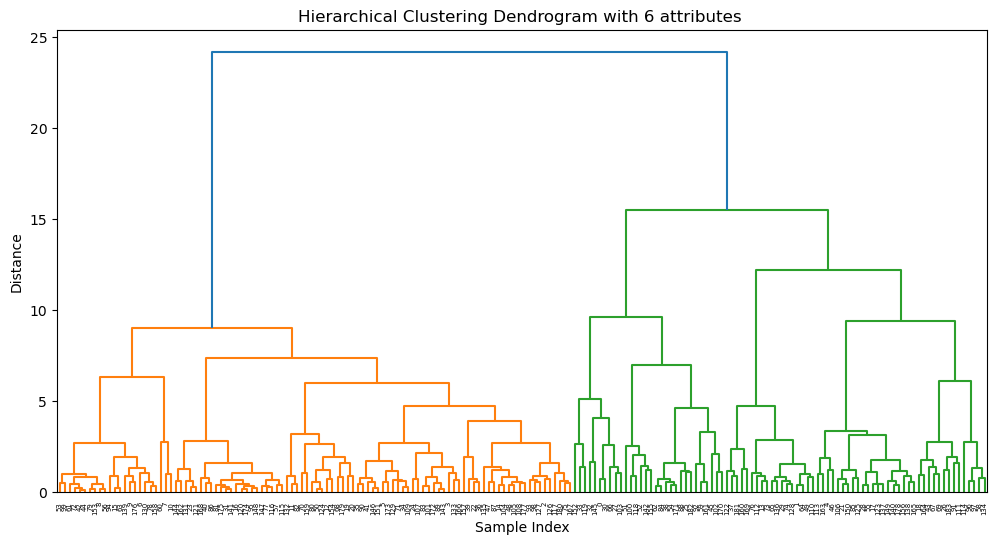

cluster
1    102
0     52
2     30
Name: count, dtype: int64
         Gross primary education enrollment (%)  Infant mortality  \
cluster                                                             
0                                      1.119769         31.492308   
1                                      1.016059          8.208824   
2                                      0.911667         48.513333   

         Maternal mortality ratio  Out of pocket health expenditure  \
cluster                                                               
0                      189.464744                          0.350423   
1                       35.750000                          0.289157   
2                      529.100000                          0.427533   

         Physicians per thousand  
cluster                           
0                       0.544808  
1                       2.846765  
2                       0.315833  


In [60]:
# 4. Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
child_df['cluster'] = clustering.fit_predict(child_df_scaled)

# 5. Create dendrogram to visualize
plt.figure(figsize=(12, 6))
Z = linkage(child_df_scaled, method='ward')
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram with 6 attributes ')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 6. View cluster assignments
print(child_df['cluster'].value_counts())
print(child_df.groupby('cluster').mean())

In [64]:
child_df['cluster']

0      2
1      0
2      1
3      1
4      0
      ..
190    1
191    1
192    0
193    2
194    0
Name: cluster, Length: 184, dtype: int64

/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9990/1367190556.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df_2['cluster'] = clustering.fit_predict(child_df_2_scaled)


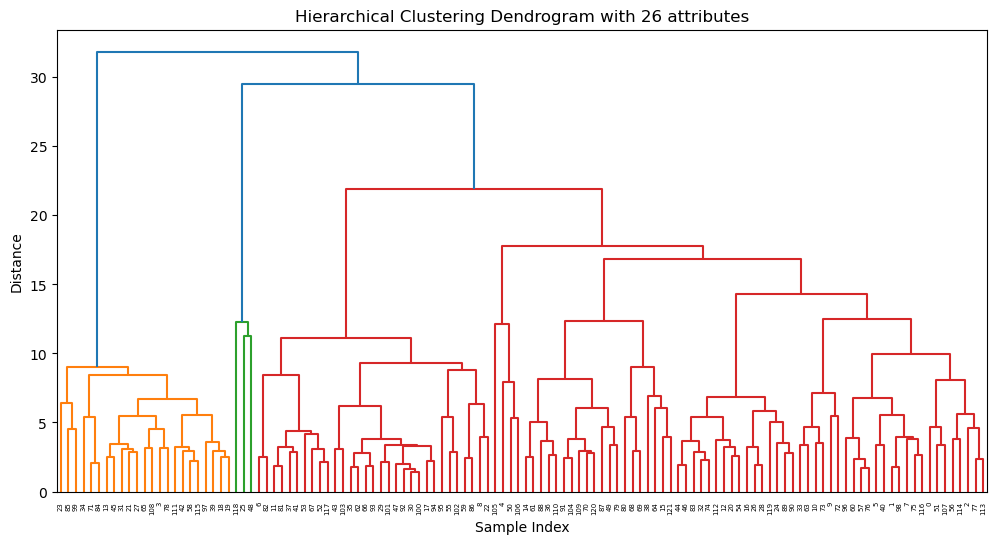

cluster
0    96
1    23
2     3
Name: count, dtype: int64
         Density\n(P/Km2)  Agricultural Land( %)  Armed Forces size  \
cluster                                                               
0              158.750000               0.000041       1.506667e+05   
1               87.130435               0.000045       3.321739e+04   
2              217.666667               0.000054       2.361667e+06   

         Birth Rate  Co2-Emissions         CPI  CPI Change (%)  \
cluster                                                          
0         16.920000   1.405069e+05  159.603438        0.000476   
1         36.193043   1.203278e+04  161.797391        0.000590   
2         13.453333   5.769004e+06  140.920000        0.000603   

         Fertility Rate  Forested Area (%)           GDP  ...  \
cluster                                                   ...   
0              2.214687           0.002975  4.089354e+11  ...   
1              4.861739           0.003563  4.723522e+10  ..

In [90]:
# 4. Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
child_df_2['cluster'] = clustering.fit_predict(child_df_2_scaled)

# 5. Create dendrogram to visualize
plt.figure(figsize=(12, 6))
Z = linkage(child_df_2_scaled, method='ward')
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram with 26 attributes')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 6. View cluster assignments
print(child_df_2['cluster'].value_counts())
print(child_df_2.groupby('cluster').mean())

In [63]:
# Show cluster assignments with country details
for cluster_num in range(3):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_num} ({len(child_df[child_df['cluster'] == cluster_num])} countries)")
    print(f"{'='*50}")
    print(child_df[child_df['cluster'] == cluster_num][['Infant mortality', 'Maternal mortality ratio']])


CLUSTER 0 (52 countries)
     Infant mortality  Maternal mortality ratio
1                 7.8                 15.000000
4                51.6                241.000000
13               25.1                173.000000
17               11.2                 36.000000
18               60.5                397.000000
22               30.0                144.000000
27               41.0                548.000000
29               16.7                 58.000000
30               24.0                160.000000
38               51.3                273.000000
45               68.2                473.000000
48               32.9                171.500000
51               18.1                 37.000000
58               21.6                 34.000000
61               32.7                252.000000
67               13.7                 25.000000
68               22.1                 95.000000
70               54.0                667.000000
72               49.5                480.000000
77            

In [61]:
# View countries in each cluster with names
for cluster_num in range(3):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_num}")
    print(f"{'='*50}")
    cluster_indices = child_df[child_df['cluster'] == cluster_num].index
    countries = df.loc[cluster_indices, 'Country']  # Adjust 'Country' to match your column name
    print(countries.tolist())


CLUSTER 0
['Albania', 'Angola', 'Bangladesh', 'Belize', 'Benin', 'Botswana', 'Burundi', 'Cape Verde', 'Cambodia', 'Comoros', 'Democratic Republic of the Congo', 'Dominica', 'Egypt', 'Fiji', 'Gabon', 'Grenada', 'Guatemala', 'Guinea-Bissau', 'Haiti', 'India', 'Indonesia', 'Iraq', 'Kiribati', 'Lesotho', 'Madagascar', 'Malawi', 'Federated States of Micronesia', 'Morocco', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Pakistan', 'Palau', 'Papua New Guinea', 'Philippines', 'Rwanda', 'Saint Lucia', 'Saint Vincent and the Grenadines', 'Samoa', 'S�����������', 'Solomon Islands', 'South Africa', 'Suriname', 'Tajikistan', 'East Timor', 'Togo', 'Tonga', 'Turkmenistan', 'Vanuatu', 'Yemen', 'Zimbabwe']

CLUSTER 1
['Algeria', 'Andorra', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'The Bahamas', 'Bahrain', 'Barbados', 'Belarus', 'Belgium', 'Bhutan', 'Bolivia', 'Brazil', 'Brunei', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyp

In [89]:
# View countries in each cluster with names
for cluster_num in range(3):
    print(f"\n{'='*50}")
    print(f"CLUSTER {cluster_num}")
    print(f"{'='*50}")
    cluster_indices = child_df_2[child_df_2['cluster'] == cluster_num].index
    countries = df.loc[cluster_indices, 'Country']  # Adjust 'Country' to match your column name
    print(countries.tolist())


CLUSTER 0
['Afghanistan', 'Albania', 'Algeria', 'Argentina', 'Armenia', 'Australia', 'Azerbaijan', 'The Bahamas', 'Bangladesh', 'Barbados', 'Belgium', 'Belize', 'Bhutan', 'Botswana', 'Brazil', 'Bulgaria', 'Cape Verde', 'Canada', 'Chile', 'Colombia', 'Costa Rica', 'Croatia', 'Czech Republic', 'Dominican Republic', 'El Salvador', 'Estonia', 'Fiji', 'France', 'Gabon', 'Georgia', 'Germany', 'Greece', 'Guatemala', 'Honduras', 'Hungary', 'Indonesia', 'Iran', 'Iraq', 'Republic of Ireland', 'Israel', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyzstan', 'Laos', 'Latvia', 'Lebanon', 'Lesotho', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Malta', 'Mauritius', 'Mexico', 'Moldova', 'Mongolia', 'Morocco', 'Myanmar', 'Nepal', 'Netherlands', 'New Zealand', 'Nicaragua', 'Oman', 'Pakistan', 'Papua New Guinea', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Romania', 'Russia', 'Saudi Arabia', 'Serbia', 'Slovakia', 'Slovenia', 'South Korea', 'Spain', 'Sri Lank

# ลองของพี่

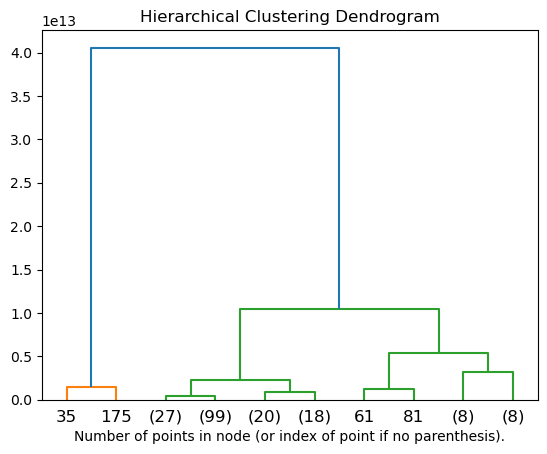

In [38]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

iris = load_iris()
X = child_df

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

In [39]:
# Set n_clusters=3 to get your 3 clusters
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
model.fit(X)

# Add cluster assignments to dataframe
child_df['cluster'] = model.labels_

# View cluster distribution
print("Cluster Distribution:")
print(child_df['cluster'].value_counts().sort_index())

# View cluster statistics
print("\nCluster Statistics:")
print(child_df.groupby('cluster').mean())

# View countries in each cluster
print("\nCountries by Cluster:")
for cluster_num in sorted(child_df['cluster'].unique()):
    print(f"\nCluster {cluster_num}:")
    cluster_countries = df.loc[child_df[child_df['cluster'] == cluster_num].index, 'Country']
    print(cluster_countries.tolist())

Cluster Distribution:
cluster
0     18
1      2
2    164
Name: count, dtype: int64

Cluster Statistics:
                  GDP  Gross primary education enrollment (%)  \
cluster                                                         
0        1.928397e+12                                1.031111   
1        2.066885e+13                                1.010000   
2        9.685667e+10                                1.028268   

         Infant mortality  Maternal mortality ratio  \
cluster                                               
0                7.227778                 29.777778   
1                6.500000                 24.000000   
2               23.092683                175.534553   

         Out of pocket health expenditure  Physicians per thousand  
cluster                                                             
0                                0.254000                 2.857778  
1                                0.217500                 2.295000  
2                 